# Level 2 - Task 2: Time Series Analysis
### Intern: Jyothi Valluru
### Dataset: Stock Prices (Focusing on AAPL)
**Objective:** Analyze historical stock data to identify trends, seasonality, and residuals. We will also apply moving average smoothing to understand price momentum.

In [ ]:
#installing required libraries
!pip install statsmodels

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Load the dataset
df = pd.read_csv('../../Dataset/Stock Prices Data Set.csv')

# 2. Convert 'date' to datetime objects
df['date'] = pd.to_datetime(df['date'])

# 3. Filter for a single stock symbol (e.g., AAPL - Apple)
# Note: Analyzing one symbol at a time is necessary for time-series decomposition
aapl_df = df[df['symbol'] == 'AAPL'].copy()

# 4. Set 'date' as the index and sort
aapl_df.set_index('date', inplace=True)
aapl_df.sort_index(inplace=True)

# 5. Handle missing values (using forward fill for stock prices)
aapl_df['close'] = aapl_df['close'].ffill()

aapl_df.head()

,symbol,open,high,low,close,volume
date,,,,,,
2014-01-02,AAPL,79.3828,79.5756,78.8601,79.0185,58791957
2014-01-03,AAPL,78.9799,79.0999,77.2042,77.2828,98303870
2014-01-06,AAPL,76.7785,78.1142,76.2285,77.7042,103359151
2014-01-07,AAPL,77.7599,77.9942,76.8464,77.1481,79432766
2014-01-08,AAPL,76.9728,77.9371,76.9556,77.6371,64686685


## 1. Identifying Patterns
We start by plotting the raw closing prices. This helps us visually identify the overall direction (Trend) and any recurring fluctuations.

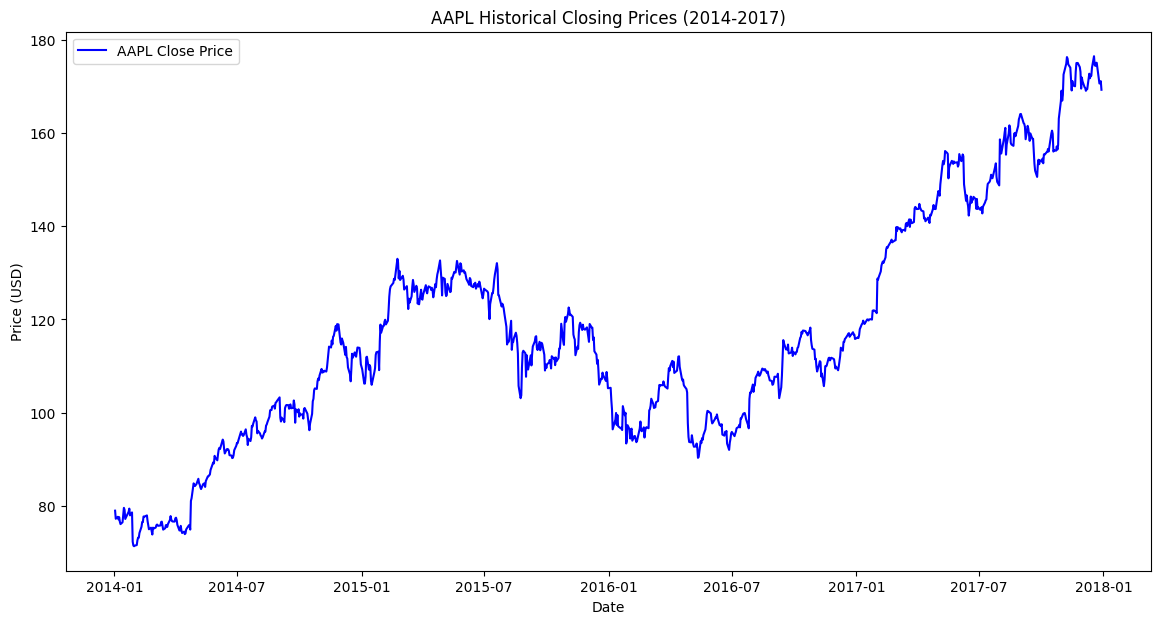

In [2]:
plt.figure(figsize=(14, 7))
plt.plot(aapl_df['close'], color='blue', label='AAPL Close Price')
plt.title('AAPL Historical Closing Prices (2014-2017)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

## 2. Time Series Decomposition
Using `statsmodels`, we break the data into three components:
- **Trend:** The long-term progression of the series.
- **Seasonality:** The repeating short-term cycle (e.g., quarterly patterns).
- **Residuals:** The random noise or "leftover" variation.

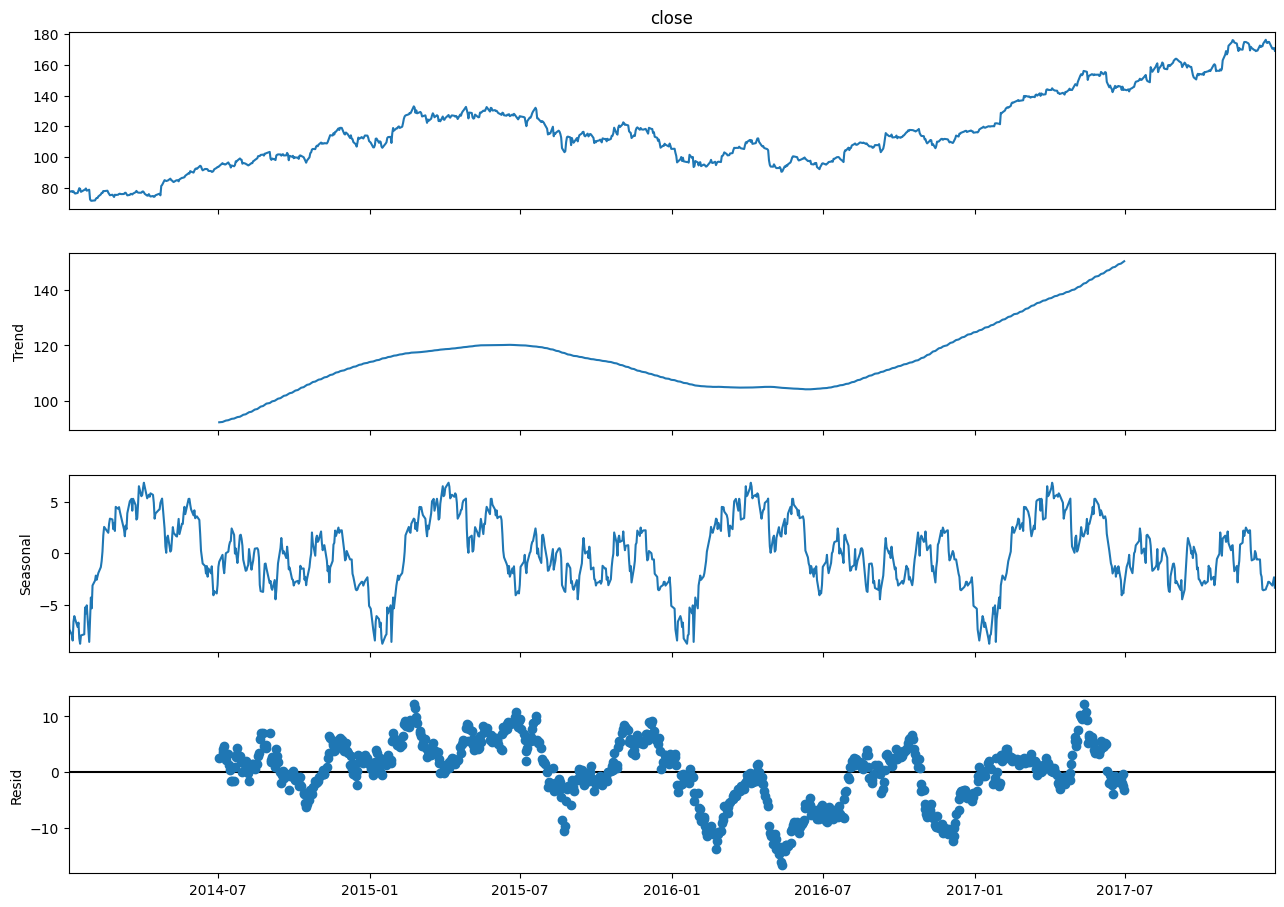

In [3]:
# We use a period of 252, which is the approximate number of trading days in a year
decomposition = seasonal_decompose(aapl_df['close'], model='additive', period=252)

# Plot the components
fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

## 3. Moving Average Smoothing
Moving averages help reduce daily price "noise" to show a clearer trend. We will calculate:
- **20-Day Moving Average:** Captures short-term momentum.
- **100-Day Moving Average:** Captures long-term trend.

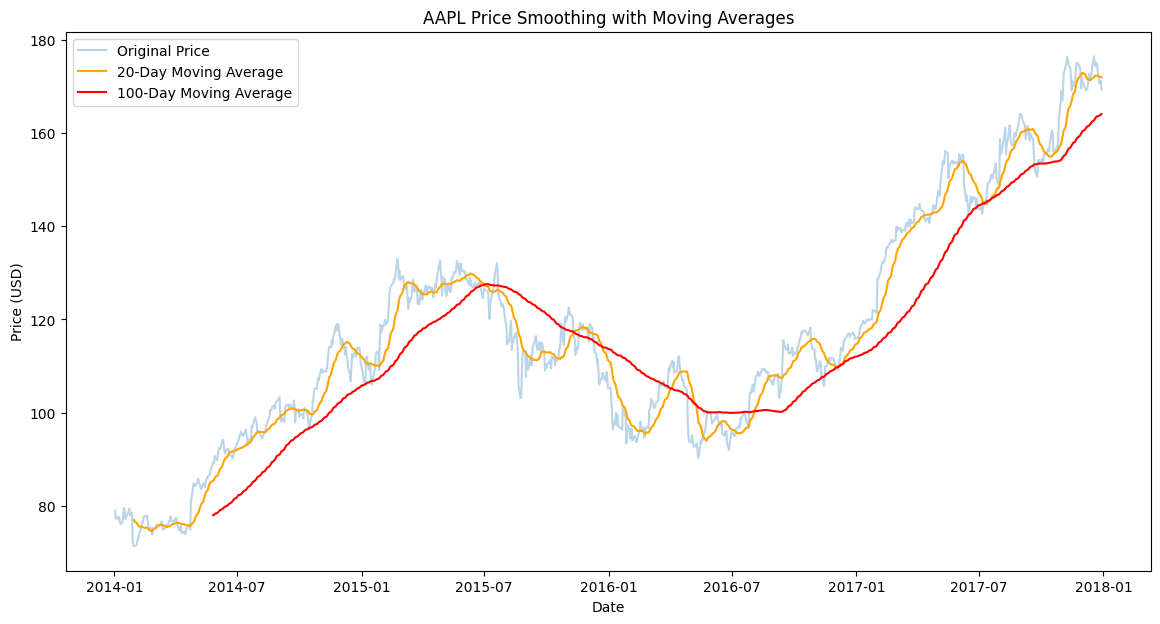

In [4]:
# Calculate moving averages
aapl_df['MA20'] = aapl_df['close'].rolling(window=20).mean()
aapl_df['MA100'] = aapl_df['close'].rolling(window=100).mean()

# Plot results
plt.figure(figsize=(14, 7))
plt.plot(aapl_df['close'], label='Original Price', alpha=0.3)
plt.plot(aapl_df['MA20'], label='20-Day Moving Average', color='orange')
plt.plot(aapl_df['MA100'], label='100-Day Moving Average', color='red')

plt.title('AAPL Price Smoothing with Moving Averages')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()

### 📈 Task 2: Time Series Insights Summary

| Component | Observation | Meaning |
| :--- | :--- | :--- |
| **Trend** | Consistently upward from 2014 to late 2017. | Indicates a strong long-term growth period for Apple. |
| **Seasonality** | Small, repeating annual fluctuations visible. | Could be related to annual product release cycles (iPhone launches). |
| **Smoothing** | Price stays above the 100-Day Moving Average. | Confirms a "Bullish" or positive market trend. |
| **Residuals** | High spikes in certain areas. | These represent unexpected news events (earnings reports or market crashes). |

**Conclusion:** The decomposition confirms that the stock price is driven primarily by its upward trend rather than seasonal cycles. The moving average crossover (where the short-term MA20 is above the long-term MA100) confirms a healthy upward momentum for the period analyzed.